In [1]:
#STEP 1-IMPORTING LIBRARIES
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [2]:
#STEP 2- LOAD DATASET
fake_path = "News _dataset/Fake.csv"
true_path = "News _dataset/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

In [3]:
#STEP 3- ADD LABELS
fake_df['label'] = 0  # Fake news
true_df['label'] = 1  # True news

In [4]:
#STEP 4- COMBINE AND SHUFFLE
data = pd.concat([fake_df, true_df], ignore_index=True)
data = data.sample(frac=1, random_state=42)  # Shuffle data

In [5]:
#STEP 5- INSPECT TEXT COLUMN
print(data.columns)
text_col = 'text'  # Replace 'text' with your actual column name
print(data[text_col].head())

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
22216    21st Century Wire says Ben Stein, reputable pr...
27917    WASHINGTON (Reuters) - U.S. President Donald T...
25007    (Reuters) - Puerto Rico Governor Ricardo Rosse...
1377     On Monday, Donald Trump once again embarrassed...
32476    GLASGOW, Scotland (Reuters) - Most U.S. presid...
Name: text, dtype: object


In [6]:
#STEP 6-PREPARE FEATURES AND LABELS
X = data[text_col].values
y = data['label'].values

In [7]:
#STEP 7-TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
#STEP 8-TF-IDF VECTORIZER
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [9]:
#STEP 9-TRAIN SVM MODEL
from sklearn.svm import LinearSVC

# LinearSVC is much faster for text data
svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train_vec, y_train)

print("SVM training completed!")
svm_model.fit

c:\Users\moham\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


SVM training completed!


<bound method LinearSVC.fit of LinearSVC(max_iter=5000, random_state=42)>

In [10]:
#STEP 10-EVALUATE MODEL
y_pred = svm_model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Test Accuracy: {accuracy*100:.2f}%")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

SVM Test Accuracy: 99.55%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      0.99      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Confusion Matrix:
[[4678   18]
 [  22 4262]]


In [11]:
#STEP 11- SAVE MODEL AND VECTORIZER
with open("svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("SVM model saved as svm_model.pkl")
print("TF-IDF vectorizer saved as tfidf_vectorizer.pkl")

SVM model saved as svm_model.pkl
TF-IDF vectorizer saved as tfidf_vectorizer.pkl


In [12]:
#STEP 12-RANDOM PREDICTION
import random

# Pick 5 random samples from the test set
num_samples = 5
indices = random.sample(range(X_test.shape[0]), num_samples)

sample_texts = X_test[indices]
sample_labels = y_test[indices]

# Transform the text using the same TF-IDF vectorizer
sample_vec = tfidf.transform(sample_texts)

# Predict labels using trained LinearSVC
sample_preds = svm_model.predict(sample_vec)

# Display results
for i, text in enumerate(sample_texts):
    actual_label = "True" if sample_labels[i] == 1 else "Fake"
    predicted_label = "True" if sample_preds[i] == 1 else "Fake"
    print(f"News: {text}")
    print(f"Actual Label: {actual_label}")
    print(f"Predicted Label: {predicted_label}")
    print("-" * 80)

News: Cliven Bundy, the leader of the Moron Militia Movement that has been threatening to kill government officials since 2014 is going to rot in a jail cell until he s convicted and sent to federal prison for the rest of his miserable life:A federal judge in Nevada refused rancher Cliven Bundy s latest request on Thursday to be freed from jail ahead of his trial on conspiracy and other felony charges for his role in a 2014 armed standoff with federal agents, a spokeswoman for prosecutors said.U.S. Magistrate Judge Carl Hoffman Jr. ruled at a hearing in Las Vegas that Bundy, 69, posed a danger to the public if released, U.S. Attorney spokeswoman Natalie Collins said in an email statement.Damn right he poses a danger! This is a man that fancies himself a  Sovereign Citizen  which means he literally does not recognize the legitimacy of the federal government. He knows, KNOWS, that he s going to be convicted for his numerous crimes which includes the aforementioned threatening to kill gov

In [13]:
# STEP 13 - USER-SPECIFIC PREDICTION (Fast, labels only)
user_articles = [
    "Government announces new tax reforms",
    "Aliens found living on Mars, shocking discovery!"
]

# Transform using the same TF-IDF vectorizer
user_vec = tfidf.transform(user_articles)

# Predict labels
user_preds = svm_model.predict(user_vec)

# Display results
for i, article in enumerate(user_articles):
    predicted_label = "True" if user_preds[i] == 1 else "Fake"
    print(f"News: {article}")
    print(f"Predicted Label: {predicted_label}\n")

News: Government announces new tax reforms
Predicted Label: Fake

News: Aliens found living on Mars, shocking discovery!
Predicted Label: Fake



Confusion Matrix:
[[4678   18]
 [  22 4262]]


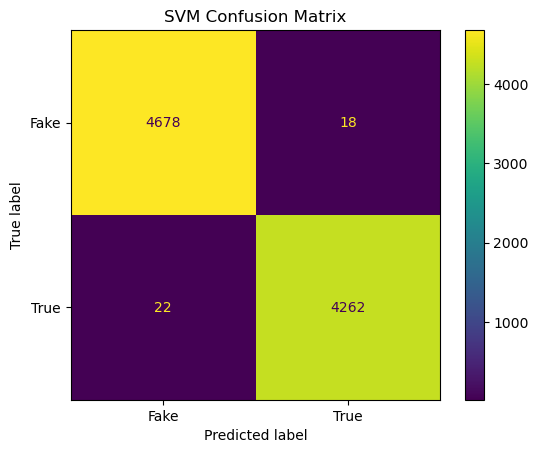

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test data
y_test_preds = svm_model.predict(X_test_vec)

# Create confusion matrix
cm = confusion_matrix(y_test, y_test_preds)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "True"])
disp.plot()

plt.title("SVM Confusion Matrix")
plt.show()